In [ ]:
#checking if T4 GPU is active
import torch
print(torch.__version__, "| GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu130 | GPU: True
Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

 cnn		    Sixflags
'Colab Notebooks'  'study material - RAG evaluation framework .gdoc'


In [ ]:
!mkdir -p /content/data
!unzip -q -o "/content/drive/MyDrive/IE7615DeepLearning.zip" -d /content/data
!ls /content/data

'IE7615 Deep Learning for AI'


In [ ]:
# Counting the images per class in the folder
import os

DATA_DIR = "/content/data/IE7615 Deep Learning for AI"

image_exts = (".jpg", ".jpeg", ".png")
counts = {}
for root, dirs, files in os.walk(DATA_DIR):
    imgs = [f for f in files if f.lower().endswith(image_exts)]
    if imgs:
        counts[os.path.relpath(root, DATA_DIR)] = len(imgs)

for folder, n in sorted(counts.items()):
    print(f"{folder:40s} {n}")
print("\nClass folders:", len(counts), "| Total images:", sum(counts.values()))

images_OBJ001                            100
images_OBJ002                            100
images_OBJ003                            100
images_OBJ004                            100
images_OBJ005                            108
images_OBJ006                            100
images_OBJ007                            100
images_OBJ008                            100
images_OBJ009                            106
images_OBJ010                            100
images_OBJ011                            100
images_OBJ012                            100
images_OBJ013                            100
images_OBJ014                            100
images_OBJ015                            100
images_OBJ016                            100
images_OBJ017                            113
images_OBJ018                            100
images_OBJ019                            100
images_OBJ020                            100
images_OBJ021                            100
images_OBJ022                            100
images_OBJ

## Step 3 : Image Validation

In [ ]:
##Image validation
#Checking that every image opens, and records image sizes and color modes. It also flags any non-image files in the folders.

from PIL import Image
from collections import Counter

bad_files, other_files = [], []
sizes, modes = Counter(), Counter()

for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        path = os.path.join(root, f)
        if not f.lower().endswith(image_exts):
            other_files.append(path)
            continue
        try:
            with Image.open(path) as img:
                img.verify()              # checks the file isn't corrupt
            with Image.open(path) as img:
                sizes[img.size] += 1
                modes[img.mode] += 1
        except Exception as e:
            bad_files.append((path, str(e)))

print("Corrupt/unreadable images:", len(bad_files))
for p, e in bad_files[:10]:
    print("  ", p, "->", e)
print("Non-image files:", len(other_files), other_files[:5])
print("Color modes:", dict(modes))
print("Most common sizes:", sizes.most_common(5))
print("Number of different sizes:", len(sizes))

Corrupt/unreadable images: 0
Non-image files: 2 ['/content/data/IE7615 Deep Learning for AI/images_OBJ036/.DS_Store', '/content/data/IE7615 Deep Learning for AI/images_OBJ036/.claude/settings.local.json']
Color modes: {'RGB': 7343}
Most common sizes: [((224, 224), 7340), ((224, 192), 1), ((225, 224), 1), ((2597, 2568), 1)]
Number of different sizes: 4


Clean results of step 3:

1. 0 corrupt images.
2. 2 junk files in images_OBJ036: a Mac .DS_Store file and a stray .claude settings folder. Neither is an image, so we should delete them.
3. All 7,343 images are already RGB, so step 6 is a formality.
4. 7,340 images are exactly 224×224. Three are odd sizes (224×192, 225×224, and one large 2597×2568). We will have resize those three in next steps.




In [ ]:
# Remove the junk files:
import shutil
obj036 = os.path.join(DATA_DIR, "images_OBJ036")
os.remove(os.path.join(obj036, ".DS_Store"))
shutil.rmtree(os.path.join(obj036, ".claude"))
print(os.listdir(obj036)[:5], len(os.listdir(obj036)))

['OBJ036_039.jpg', 'OBJ036_010.jpg', 'OBJ036_017.jpg', 'OBJ036_050.jpg', 'OBJ036_068.jpg'] 100


## Step 4: Exact duplicate check

In [ ]:
import hashlib
from collections import defaultdict

hash_to_files = defaultdict(list)
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(image_exts):
            path = os.path.join(root, f)
            with open(path, "rb") as fh:
                h = hashlib.md5(fh.read()).hexdigest()
            hash_to_files[h].append(path)

dup_groups = {h: p for h, p in hash_to_files.items() if len(p) > 1}
extra_copies = sum(len(p) - 1 for p in dup_groups.values())
cross_class = [p for p in dup_groups.values()
               if len({os.path.basename(os.path.dirname(x)) for x in p}) > 1]

print("Duplicate groups:", len(dup_groups))
print("Extra copies to remove:", extra_copies)
print("Groups spanning different classes:", len(cross_class))
for p in list(dup_groups.values())[:5]:
    print([os.path.relpath(x, DATA_DIR) for x in p])

Duplicate groups: 28
Extra copies to remove: 28
Groups spanning different classes: 0
['images_OBJ053/OBJ053_bg_006.jpg', 'images_OBJ053/OBJ053_bg_001.jpg']
['images_OBJ053/OBJ053_bg_008.jpg', 'images_OBJ053/OBJ053_bg_003.jpg']
['images_OBJ053/OBJ053_bg_004.jpg', 'images_OBJ053/OBJ053_bg_009.jpg']
['images_OBJ053/OBJ053_bg_007.jpg', 'images_OBJ053/OBJ053_bg_002.jpg']
['images_OBJ053/OBJ053_bg_010.jpg', 'images_OBJ053/OBJ053_bg_005.jpg']


All 28 duplicates are pairs inside the same class, and none cross classes, so no labeling conflicts.

Removing one copy from each pair, and keeping the file with the lower number, and saving a log for the report:

In [ ]:
import pandas as pd

removed = []
for paths in dup_groups.values():
    keep, *drop = sorted(paths)
    for p in drop:
        os.remove(p)
        removed.append({"removed": os.path.relpath(p, DATA_DIR),
                        "duplicate_of": os.path.relpath(keep, DATA_DIR)})

pd.DataFrame(removed).to_csv("/content/removed_duplicates.csv", index=False)

# recount per class
counts = {}
for d in sorted(os.listdir(DATA_DIR)):
    full = os.path.join(DATA_DIR, d)
    if os.path.isdir(full):
        counts[d] = len([f for f in os.listdir(full) if f.lower().endswith(image_exts)])

print("Removed:", len(removed))
print("Total images now:", sum(counts.values()))
print("Classes not at 100:", {k: v for k, v in counts.items() if v != 100})

Removed: 28
Total images now: 7315
Classes not at 100: {'images_OBJ002': 99, 'images_OBJ005': 108, 'images_OBJ009': 106, 'images_OBJ011': 98, 'images_OBJ017': 113, 'images_OBJ022': 99, 'images_OBJ023': 94, 'images_OBJ029': 99, 'images_OBJ049': 105, 'images_OBJ051': 110, 'images_OBJ053': 95, 'images_OBJ062': 96, 'images_OBJ065': 95, 'images_OBJ066': 99, 'images_OBJ067': 99}


## Steps 5 and 6: Resize and RGB conversion

Only three images need resizing. All three are almost square, so resizing straight to 224×224 won't visibly distort them. Every image is already RGB, but this guarantees it.

In [ ]:
TARGET = (224, 224)
resized = []

for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if not f.lower().endswith(image_exts):
            continue
        path = os.path.join(root, f)
        with Image.open(path) as img:
            needs_resize = img.size != TARGET
            needs_rgb = img.mode != "RGB"
            if needs_resize or needs_rgb:
                old_size = img.size
                img = img.convert("RGB").resize(TARGET, Image.LANCZOS)
                img.save(path, quality=95)
                resized.append((os.path.relpath(path, DATA_DIR), old_size))

print("Images changed:", len(resized))
for p, s in resized:
    print(f"  {p}: {s} -> {TARGET}")

# verify
sizes, modes = Counter(), Counter()
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(image_exts):
            with Image.open(os.path.join(root, f)) as img:
                sizes[img.size] += 1
                modes[img.mode] += 1
print("Sizes:", dict(sizes))
print("Modes:", dict(modes))

Images changed: 3
  images_OBJ003/OBJ003_072.jpg: (224, 192) -> (224, 224)
  images_OBJ023/OBJ023_001.JPG: (225, 224) -> (224, 224)
  images_OBJ023/OBJ023_bg_001.JPG: (2597, 2568) -> (224, 224)
Sizes: {(224, 224): 7315}
Modes: {'RGB': 7315}


## Step 7: Train/validation/test split

In [ ]:
from sklearn.model_selection import train_test_split

# build a table of (image path, class)
rows = []
for d in sorted(os.listdir(DATA_DIR)):
    full = os.path.join(DATA_DIR, d)
    if os.path.isdir(full):
        for f in sorted(os.listdir(full)):
            if f.lower().endswith(image_exts):
                rows.append({"path": os.path.join(d, f), "label": d})
df = pd.DataFrame(rows)

classes = sorted(df["label"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df["label_idx"] = df["label"].map(class_to_idx)

# 70% train, then split the remaining 30% in half -> 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    per_class = d["label"].value_counts()
    print(f"{name}: {per_class.min()}–{per_class.max()} images per class")

# save splits + cleaned dataset to Drive
SAVE_DIR = "/content/drive/MyDrive/IE7615_project"
os.makedirs(SAVE_DIR, exist_ok=True)
train_df.to_csv(f"{SAVE_DIR}/train.csv", index=False)
val_df.to_csv(f"{SAVE_DIR}/val.csv", index=False)
test_df.to_csv(f"{SAVE_DIR}/test.csv", index=False)
shutil.copy("/content/removed_duplicates.csv", SAVE_DIR)
shutil.make_archive(f"{SAVE_DIR}/clean_dataset", "zip", DATA_DIR)
print("Saved to", SAVE_DIR)

Train: 5120 | Val: 1097 | Test: 1098
train: 66–79 images per class
val: 14–17 images per class
test: 14–17 images per class
Saved to /content/drive/MyDrive/IE7615_project


5,120 train, 1,097 validation, 1,098 test. Every class has at least 14 test images.

## Step 8: Normalization and augmentation

This cell defines how images are loaded and transformed, then builds the data loaders that feed the models. Training images get random augmentation every epoch. Validation and test images only get normalized, since they're already 224×224.

Batch shape: torch.Size([64, 3, 224, 224]) | Labels: [63, 27, 5, 68, 70, 17, 52, 34]


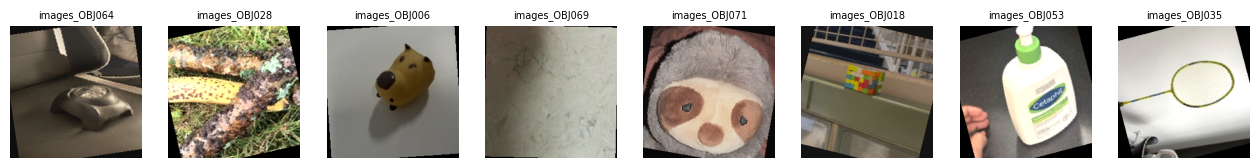

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # ImageNet stats

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25),     # simulates occlusion
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class ObjectDataset(Dataset):
    def __init__(self, df, root, transform):
        self.paths = df["path"].tolist()
        self.labels = df["label_idx"].tolist()
        self.root, self.transform = root, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(os.path.join(self.root, self.paths[i])).convert("RGB")
        return self.transform(img), self.labels[i]

BATCH = 64
train_loader = DataLoader(ObjectDataset(train_df, DATA_DIR, train_tf), batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(ObjectDataset(val_df, DATA_DIR, eval_tf), batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ObjectDataset(test_df, DATA_DIR, eval_tf), batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# sanity check: one batch + preview of augmented training images
x, y = next(iter(train_loader))
print("Batch shape:", x.shape, "| Labels:", y[:8].tolist())

imgs = x[:8] * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1)
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for ax, img, lbl in zip(axes, imgs, y[:8]):
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1)); ax.set_title(classes[lbl], fontsize=7); ax.axis("off")
plt.show()

the augmentation looks as intended: rotated, cropped, and color-shifted versions of real objects. The black corners come from the rotation(treating it as normal for now)

## Step 9a: Shared training code

defining the training and evaluation functions every model will use, so the comparison is fair. It saves the best checkpoint, the epoch-by-epoch history, and the final results to my Drive.

In [ ]:
import time, json
import torch.nn as nn
from sklearn.metrics import f1_score

device = "cuda"
NUM_CLASSES = len(classes)
RESULTS = {}

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
        for x, y in loader:
            out = model(x.to(device, non_blocking=True))
            preds.append(out.argmax(1).cpu()); labels.append(y)
    preds, labels = torch.cat(preds).numpy(), torch.cat(labels).numpy()
    return (preds == labels).mean(), f1_score(labels, preds, average="macro"), preds, labels

def train_model(name, model, epochs, lr):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    history, best_val, start = [], 0.0, time.time()

    for ep in range(1, epochs + 1):
        model.train(); total, correct, loss_sum = 0, 0, 0.0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.autocast("cuda", dtype=torch.float16):
                out = model(x); loss = criterion(out, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            loss_sum += loss.item() * len(y); correct += (out.argmax(1) == y).sum().item(); total += len(y)
        sched.step()

        val_acc, val_f1, _, _ = evaluate(model, val_loader)
        history.append({"epoch": ep, "train_loss": loss_sum / total,
                        "train_acc": correct / total, "val_acc": val_acc, "val_f1": val_f1})
        flag = ""
        if val_acc > best_val:
            best_val = val_acc; torch.save(model.state_dict(), f"{SAVE_DIR}/{name}.pt"); flag = "  <- best"
        print(f"[{name}] epoch {ep:2d}/{epochs} | loss {loss_sum/total:.3f} | "
              f"train {correct/total:.3f} | val {val_acc:.3f} | val F1 {val_f1:.3f}{flag}")

    train_time = (time.time() - start) / 60
    model.load_state_dict(torch.load(f"{SAVE_DIR}/{name}.pt"))
    test_acc, test_f1, preds, labels = evaluate(model, test_loader)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6

    RESULTS[name] = {"best_val_acc": best_val, "test_acc": test_acc, "test_macro_f1": test_f1,
                     "params_M": round(n_params, 2), "train_min": round(train_time, 1),
                     "test_errors": int((preds != labels).sum())}
    pd.DataFrame(history).to_csv(f"{SAVE_DIR}/{name}_history.csv", index=False)
    np.save(f"{SAVE_DIR}/{name}_test_preds.npy", preds)
    with open(f"{SAVE_DIR}/results.json", "w") as f:
        json.dump(RESULTS, f, indent=2, default=float)
    print(f"\n{name} DONE | test acc {test_acc:.4f} | macro-F1 {test_f1:.4f} | "
          f"{n_params:.2f}M params | {train_time:.1f} min | {RESULTS[name]['test_errors']} errors")
    return model

import numpy as np
print("Ready. Classes:", NUM_CLASSES)

Ready. Classes: 73


## Step 9b: Model A, Custom CNN

This model has five convolutional blocks, each with two conv layers, BatchNorm and max pooling. Then come global average pooling, dropout and the classifier. A model trained from scratch needs more epochs, so we give it 30.

In [ ]:
def conv_block(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        nn.Conv2d(c_out, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        nn.MaxPool2d(2))

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64), conv_block(64, 128),
            conv_block(128, 256), conv_block(256, 512))          # 224 -> 7
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(512, num_classes))
    def forward(self, x):
        return self.head(self.features(x))

model_A = train_model("A_custom_cnn", CustomCNN(NUM_CLASSES), epochs=30, lr=1e-3)

[A_custom_cnn] epoch  1/30 | loss 4.243 | train 0.031 | val 0.056 | val F1 0.028  <- best
[A_custom_cnn] epoch  2/30 | loss 4.002 | train 0.064 | val 0.087 | val F1 0.057  <- best
[A_custom_cnn] epoch  3/30 | loss 3.884 | train 0.087 | val 0.106 | val F1 0.073  <- best
[A_custom_cnn] epoch  4/30 | loss 3.765 | train 0.109 | val 0.143 | val F1 0.110  <- best
[A_custom_cnn] epoch  5/30 | loss 3.666 | train 0.148 | val 0.143 | val F1 0.102
[A_custom_cnn] epoch  6/30 | loss 3.546 | train 0.172 | val 0.227 | val F1 0.189  <- best
[A_custom_cnn] epoch  7/30 | loss 3.421 | train 0.204 | val 0.206 | val F1 0.171
[A_custom_cnn] epoch  8/30 | loss 3.300 | train 0.238 | val 0.295 | val F1 0.251  <- best
[A_custom_cnn] epoch  9/30 | loss 3.193 | train 0.272 | val 0.288 | val F1 0.267
[A_custom_cnn] epoch 10/30 | loss 3.066 | train 0.303 | val 0.330 | val F1 0.295  <- best
[A_custom_cnn] epoch 11/30 | loss 2.969 | train 0.340 | val 0.344 | val F1 0.311  <- best
[A_custom_cnn] epoch 12/30 | loss 2.8

## Model B: MobileNetV3-Large

In [ ]:
from torchvision import models

m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
m.classifier[3] = nn.Linear(m.classifier[3].in_features, NUM_CLASSES)
model_B = train_model("B_mobilenetv3_large", m, epochs=15, lr=3e-4)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 85.7MB/s]


[B_mobilenetv3_large] epoch  1/15 | loss 2.525 | train 0.581 | val 0.824 | val F1 0.830  <- best
[B_mobilenetv3_large] epoch  2/15 | loss 1.183 | train 0.910 | val 0.911 | val F1 0.911  <- best
[B_mobilenetv3_large] epoch  3/15 | loss 1.023 | train 0.952 | val 0.928 | val F1 0.928  <- best
[B_mobilenetv3_large] epoch  4/15 | loss 0.956 | train 0.970 | val 0.937 | val F1 0.938  <- best
[B_mobilenetv3_large] epoch  5/15 | loss 0.906 | train 0.981 | val 0.945 | val F1 0.946  <- best
[B_mobilenetv3_large] epoch  6/15 | loss 0.874 | train 0.988 | val 0.947 | val F1 0.948  <- best
[B_mobilenetv3_large] epoch  7/15 | loss 0.862 | train 0.990 | val 0.947 | val F1 0.947
[B_mobilenetv3_large] epoch  8/15 | loss 0.846 | train 0.991 | val 0.945 | val F1 0.946
[B_mobilenetv3_large] epoch  9/15 | loss 0.832 | train 0.993 | val 0.949 | val F1 0.949  <- best
[B_mobilenetv3_large] epoch 10/15 | loss 0.834 | train 0.993 | val 0.951 | val F1 0.951  <- best
[B_mobilenetv3_large] epoch 11/15 | loss 0.829 |

## Model C: DenseNet-121

In [ ]:
m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
m.classifier = nn.Linear(m.classifier.in_features, NUM_CLASSES)
model_C = train_model("C_densenet121", m, epochs=15, lr=3e-4)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 193MB/s]


[C_densenet121] epoch  1/15 | loss 2.607 | train 0.605 | val 0.841 | val F1 0.847  <- best
[C_densenet121] epoch  2/15 | loss 1.257 | train 0.900 | val 0.886 | val F1 0.889  <- best
[C_densenet121] epoch  3/15 | loss 1.032 | train 0.942 | val 0.927 | val F1 0.928  <- best
[C_densenet121] epoch  4/15 | loss 0.944 | train 0.961 | val 0.920 | val F1 0.921
[C_densenet121] epoch  5/15 | loss 0.910 | train 0.969 | val 0.936 | val F1 0.937  <- best
[C_densenet121] epoch  6/15 | loss 0.877 | train 0.980 | val 0.941 | val F1 0.942  <- best
[C_densenet121] epoch  7/15 | loss 0.859 | train 0.984 | val 0.943 | val F1 0.945  <- best
[C_densenet121] epoch  8/15 | loss 0.826 | train 0.992 | val 0.950 | val F1 0.950  <- best
[C_densenet121] epoch  9/15 | loss 0.827 | train 0.990 | val 0.954 | val F1 0.954  <- best
[C_densenet121] epoch 10/15 | loss 0.821 | train 0.991 | val 0.954 | val F1 0.954
[C_densenet121] epoch 11/15 | loss 0.804 | train 0.995 | val 0.958 | val F1 0.959  <- best
[C_densenet121] e

## EfficientNetV2-S

In [ ]:
m = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
model_D = train_model("D_efficientnetv2_s", m, epochs=15, lr=3e-4)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 191MB/s]


[D_efficientnetv2_s] epoch  1/15 | loss 2.388 | train 0.644 | val 0.890 | val F1 0.890  <- best
[D_efficientnetv2_s] epoch  2/15 | loss 1.077 | train 0.918 | val 0.918 | val F1 0.922  <- best
[D_efficientnetv2_s] epoch  3/15 | loss 0.953 | train 0.952 | val 0.936 | val F1 0.937  <- best
[D_efficientnetv2_s] epoch  4/15 | loss 0.887 | train 0.970 | val 0.933 | val F1 0.933
[D_efficientnetv2_s] epoch  5/15 | loss 0.865 | train 0.975 | val 0.938 | val F1 0.938  <- best
[D_efficientnetv2_s] epoch  6/15 | loss 0.834 | train 0.982 | val 0.946 | val F1 0.946  <- best
[D_efficientnetv2_s] epoch  7/15 | loss 0.820 | train 0.986 | val 0.947 | val F1 0.948  <- best
[D_efficientnetv2_s] epoch  8/15 | loss 0.800 | train 0.993 | val 0.943 | val F1 0.944
[D_efficientnetv2_s] epoch  9/15 | loss 0.797 | train 0.992 | val 0.953 | val F1 0.953  <- best
[D_efficientnetv2_s] epoch 10/15 | loss 0.787 | train 0.994 | val 0.954 | val F1 0.954  <- best
[D_efficientnetv2_s] epoch 11/15 | loss 0.784 | train 0.99

In [ ]:
from scipy.stats import binomtest

names = ["A_custom_cnn", "B_mobilenetv3_large", "C_densenet121", "D_efficientnetv2_s"]
y_test = test_df["label_idx"].values

table = pd.DataFrame(RESULTS).T[["best_val_acc", "test_acc", "test_macro_f1",
                                  "params_M", "train_min", "test_errors"]]
print(table.round(4), "\n")
table.to_csv(f"{SAVE_DIR}/comparison_table.csv")

# McNemar test: does C really beat each other model, or is it a tie?
preds = {n: np.load(f"{SAVE_DIR}/{n}_test_preds.npy") for n in names}
best = "C_densenet121"
for n in names:
    if n == best:
        continue
    c_right = preds[best] == y_test
    o_right = preds[n] == y_test
    only_c, only_o = int((c_right & ~o_right).sum()), int((~c_right & o_right).sum())
    p = binomtest(only_c, only_c + only_o, 0.5).pvalue if only_c + only_o else 1.0
    print(f"{best} vs {n}: C right/other wrong = {only_c}, "
          f"other right/C wrong = {only_o}, McNemar p = {p:.3f}")

                     best_val_acc  test_acc  test_macro_f1  params_M  \
A_custom_cnn               0.7293    0.7359         0.7305      4.75   
B_mobilenetv3_large        0.9553    0.9563         0.9562      4.30   
C_densenet121              0.9617    0.9645         0.9650      7.03   
D_efficientnetv2_s         0.9572    0.9636         0.9632     20.27   

                     train_min  test_errors  
A_custom_cnn              17.4        290.0  
B_mobilenetv3_large        7.9         48.0  
C_densenet121              9.1         39.0  
D_efficientnetv2_s         9.5         40.0   

C_densenet121 vs A_custom_cnn: C right/other wrong = 255, other right/C wrong = 4, McNemar p = 0.000
C_densenet121 vs B_mobilenetv3_large: C right/other wrong = 19, other right/C wrong = 10, McNemar p = 0.136
C_densenet121 vs D_efficientnetv2_s: C right/other wrong = 10, other right/C wrong = 9, McNemar p = 1.000


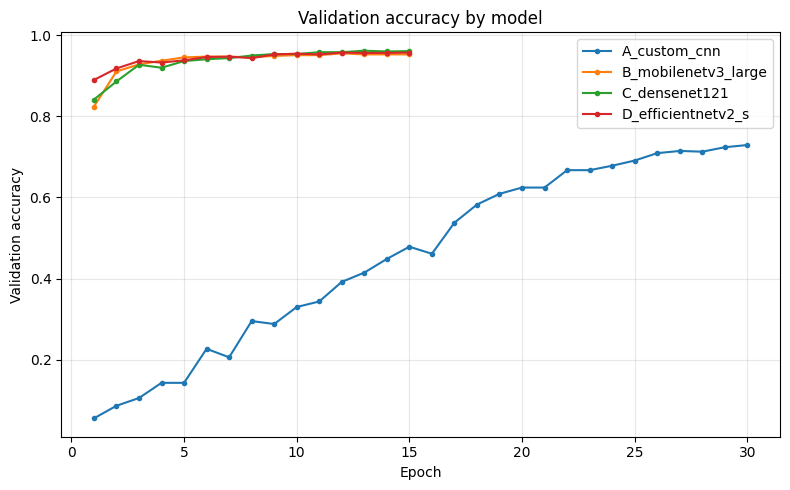

Weakest classes (DenseNet-121):
  images_OBJ034     73.3%  (11/15)
  images_OBJ039     80.0%  (12/15)
  images_OBJ005     81.2%  (13/16)
  images_OBJ013     86.7%  (13/15)
  images_OBJ052     86.7%  (13/15)
  images_OBJ061     86.7%  (13/15)
  images_OBJ026     86.7%  (13/15)
  images_OBJ057     86.7%  (13/15)
  images_OBJ059     86.7%  (13/15)
  images_OBJ011     92.9%  (13/14)

Most confused pairs (true -> predicted):
  images_OBJ052 -> images_OBJ017: 2
  images_OBJ039 -> images_OBJ013: 2
  images_OBJ034 -> images_OBJ013: 2
  images_OBJ059 -> images_OBJ061: 2
  images_OBJ005 -> images_OBJ063: 2
  images_OBJ038 -> images_OBJ047: 1
  images_OBJ004 -> images_OBJ036: 1
  images_OBJ061 -> images_OBJ059: 1
  images_OBJ039 -> images_OBJ061: 1
  images_OBJ040 -> images_OBJ028: 1


In [ ]:
from sklearn.metrics import confusion_matrix
from collections import Counter

# 1. Validation accuracy curves for all models
plt.figure(figsize=(8, 5))
for n in names:
    h = pd.read_csv(f"{SAVE_DIR}/{n}_history.csv")
    plt.plot(h["epoch"], h["val_acc"], marker="o", markersize=3, label=n)
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy"); plt.title("Validation accuracy by model")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/val_curves.png", dpi=150); plt.show()

# 2. Error analysis for the chosen model
p = preds["C_densenet121"]
cm = confusion_matrix(y_test, p, labels=range(NUM_CLASSES))

per_class = cm.diagonal() / cm.sum(axis=1)
worst = np.argsort(per_class)[:10]
print("Weakest classes (DenseNet-121):")
for i in worst:
    print(f"  {classes[i]:16s} {per_class[i]*100:5.1f}%  ({cm[i,i]}/{cm[i].sum()})")

confused = Counter((classes[t], classes[q]) for t, q in zip(y_test, p) if t != q)
print("\nMost confused pairs (true -> predicted):")
for (t, q), c in confused.most_common(10):
    print(f"  {t} -> {q}: {c}")